# General Linear Models using Python

## Objective

The objective of this project is to study the relationship between the Happiness Score and various socio-economic factors using Linear Regression models.

The analysis is carried out in two stages:

- **Simple Linear Regression (SLRM):** Examines the effect of each predictor individually.
- **Multiple Linear Regression (MLRM):** Examines the combined effect of all predictors.

The dataset is based on the World Happiness Report.

### Variables

**Dependent Variable**

- Y : Happiness Score

**Independent Variables**

- X1 : Economy (GDP per Capita)
- X2 : Family
- X3 : Health (Life Expectancy)
- X4 : Freedom
- X5 : Trust (Government Corruption)
- X6 : Generosity

The analysis includes model fitting, hypothesis testing, confidence intervals, prediction intervals, residual analysis, standardized residuals, and stepwise regression.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.style.use("ggplot")

import seaborn as sns

from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf

from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

In [3]:
# Load the dataset
path = "/Users/ishagoel/Downloads/happiness.xlsx"
df = pd.read_excel(path)

df.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811


In [5]:
# Shape of the dataset
print("Shape of dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

Shape of dataset: (158, 11)

Column Names:
['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity']

Data Types:


Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
dtype: object


Missing Values:


Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
dtype: int64

In [15]:
df = df.rename(columns={
    "Happiness Score": "Y",
    "Economy (GDP per Capita)": "X1",
    "Family": "X2",
    "Health (Life Expectancy)": "X3",
    "Freedom": "X4",
    "Trust (Government Corruption)": "X5",
    "Generosity": "X6"
})

df.head()

,Country,Region,Happiness Rank,Y,Standard Error,X1,X2,X3,X4,X5,X6
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Happiness Rank,158.0,79.493671,45.754363,1.00000,40.250000,79.500000,118.750000,158.00000
Y,158.0,5.375734,1.145010,2.83900,4.526000,5.232500,6.243750,7.58700
Standard Error,158.0,0.047885,0.017146,0.01848,0.037268,0.043940,0.052300,0.13693
X1,158.0,0.846137,0.403121,0.00000,0.545808,0.910245,1.158448,1.69042
X2,158.0,0.991046,0.272369,0.00000,0.856823,1.029510,1.214405,1.40223
X3,158.0,0.630259,0.247078,0.00000,0.439185,0.696705,0.811013,1.02525
X4,158.0,0.428615,0.150693,0.00000,0.328330,0.435515,0.549092,0.66973
X5,158.0,0.143422,0.120034,0.00000,0.061675,0.107220,0.180255,0.55191
X6,158.0,0.237296,0.126685,0.00000,0.150553,0.216130,0.309883,0.79588


In [19]:
corr = df[["Y","X1","X2","X3","X4","X5","X6"]].corr()

corr

,Y,X1,X2,X3,X4,X5,X6
Y,1.000000,0.780966,0.740605,0.724200,0.568211,0.395199,0.180319
X1,0.780966,1.000000,0.645299,0.816478,0.370300,0.307885,-0.010465
X2,0.740605,0.645299,1.000000,0.531104,0.441518,0.205605,0.087513
X3,0.724200,0.816478,0.531104,1.000000,0.360477,0.248335,0.108335
X4,0.568211,0.370300,0.441518,0.360477,1.000000,0.493524,0.373916
X5,0.395199,0.307885,0.205605,0.248335,0.493524,1.000000,0.276123
X6,0.180319,-0.010465,0.087513,0.108335,0.373916,0.276123,1.000000


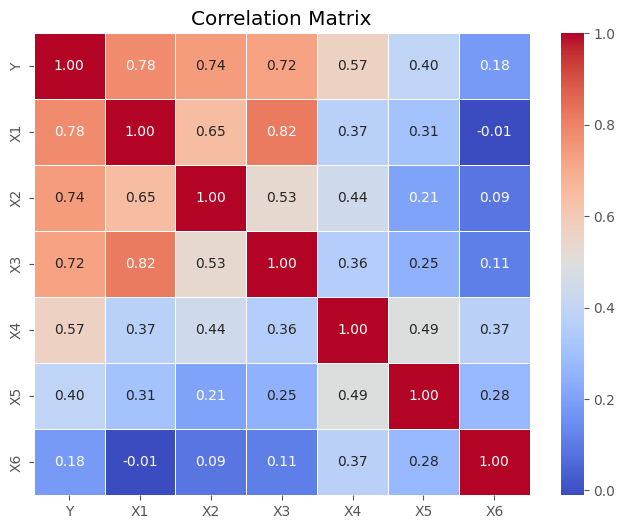

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.show()

# Simple Linear Regression

## Model 1 : Happiness Score (Y) vs Economy (GDP per Capita) (X1)

A Simple Linear Regression model is fitted to study the relationship between the Happiness Score and Economy (GDP per Capita).

The model is given by

\[
Y=\beta_0+\beta_1X_1+\varepsilon
\]

where

- **Y** : Happiness Score
- **X1** : Economy (GDP per Capita)
- **β₀** : Intercept
- **β₁** : Regression coefficient
- **ε** : Random error

In [32]:
# Define predictor and response

X = sm.add_constant(df["X1"])
Y = df["Y"]

# Fit Simple Linear Regression

slr_x1 = smf.ols("Y ~ X1", data=df).fit()

In [36]:
intercept = slr_x1.params["Intercept"]
slope = slr_x1.params["X1"]

print(f"Intercept : {intercept:.6f}")
print(f"Slope     : {slope:.6f}")

print("\nFitted Model")

print(f"Y = {intercept:.6f} + ({slope:.6f}) X1")

Intercept : 3.498810
Slope     : 2.218227

Fitted Model
Y = 3.498810 + (2.218227) X1


In [38]:
slr_x1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.610
Model:                            OLS   Adj. R-squared:                  0.607
Method:                 Least Squares   F-statistic:                     243.9
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           1.05e-33
Time:                        22:10:19   Log-Likelihood:                -170.72
No. Observations:                 158   AIC:                             345.4
Df Residuals:                     156   BIC:                             351.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4988      0.133     26.298      0.000       3.236       3.762
X1             2.2182      0.142     15.617      0.000       1.938       2.499
==============================================================================
Omnibus:                        1.643   Durbin-Watson:                   1.103
Prob(Omnibus):                  0.440   Jarque-Bera (JB):                1.485
Skew:                          -0.112   Prob(JB):                        0.476
Kurtosis:                       2.581   Cond. No.                         4.45
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
from statsmodels.stats.anova import anova_lm

anova_table = anova_lm(slr_x1)

anova_table

,df,sum_sq,mean_sq,F,PR(>F)
X1,1.0,125.539976,125.539976,243.904796,1.050538e-33
Residual,156.0,80.294593,0.514709,NaN,NaN


In [42]:
coef_table = pd.DataFrame({
    "Coefficient": slr_x1.params,
    "Std. Error": slr_x1.bse,
    "t Statistic": slr_x1.tvalues,
    "P-value": slr_x1.pvalues,
    "Lower 95% CI": slr_x1.conf_int()[0],
    "Upper 95% CI": slr_x1.conf_int()[1]
})

coef_table

,Coefficient,Std. Error,t Statistic,P-value,Lower 95% CI,Upper 95% CI
Intercept,3.498810,0.133046,26.297788,3.266714e-59,3.236006,3.761613
X1,2.218227,0.142035,15.617452,1.050538e-33,1.937667,2.498787


### Hypothesis Test for the Regression Coefficient

The hypotheses are:

- **H₀:** β₁ = 0 (There is no significant linear relationship between X1 and Y.)
- **H₁:** β₁ ≠ 0 (There is a significant linear relationship between X1 and Y.)

Since the p-value (1.05 × 10⁻³³) is less than the significance level of 0.05, we reject the null hypothesis.

**Conclusion:** There is sufficient statistical evidence to conclude that Economy (GDP per Capita) has a significant linear relationship with the Happiness Score.

In [46]:
pvalue = slr_x1.pvalues["X1"]

print("P-value =", pvalue)

if pvalue < 0.05:
    print("\nDecision : Reject H₀")
    print("Conclusion : There exists a significant linear relationship between X1 and Y.")
else:
    print("\nDecision : Fail to Reject H₀")
    print("Conclusion : There is no significant linear relationship between X1 and Y.")

P-value = 1.0505384131959142e-33

Decision : Reject H₀
Conclusion : There exists a significant linear relationship between X1 and Y.


In [48]:
slr_x1.conf_int().rename(columns={0:"Lower Limit",1:"Upper Limit"})

,Lower Limit,Upper Limit
Intercept,3.236006,3.761613
X1,1.937667,2.498787


In [50]:
r2 = slr_x1.rsquared

print("R² =", round(r2,4))
print("Percentage Explained =", round(r2*100,2),"%")

R² = 0.6099
Percentage Explained = 60.99 %


## Residual Analysis

Residual analysis is performed to verify whether the assumptions of linear regression are satisfied.

The following diagnostic plots are considered:

- Normal Q-Q Plot
- Residuals vs Fitted Values
- Residuals vs Predictor

In [53]:
residuals = slr_x1.resid
fitted = slr_x1.fittedvalues

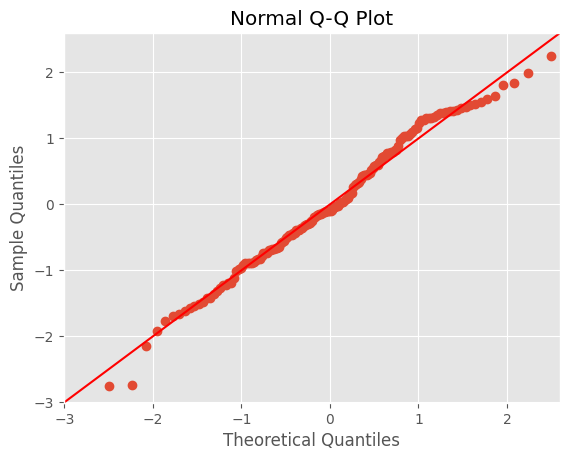

In [55]:
sm.qqplot(residuals, line="45", fit=True)

plt.title("Normal Q-Q Plot")
plt.show()

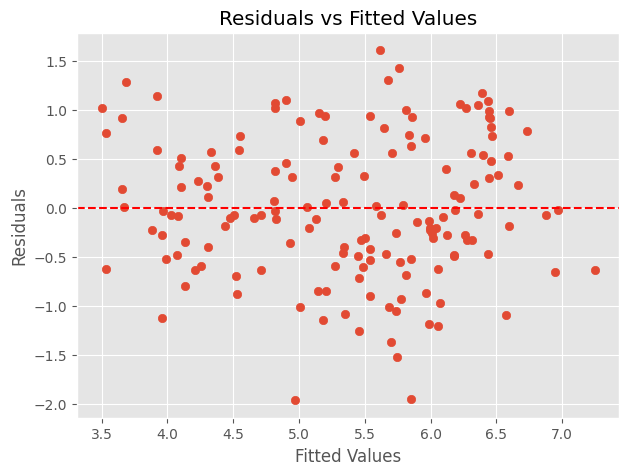

In [57]:
plt.figure(figsize=(7,5))

plt.scatter(fitted, residuals)

plt.axhline(0,color="red",linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

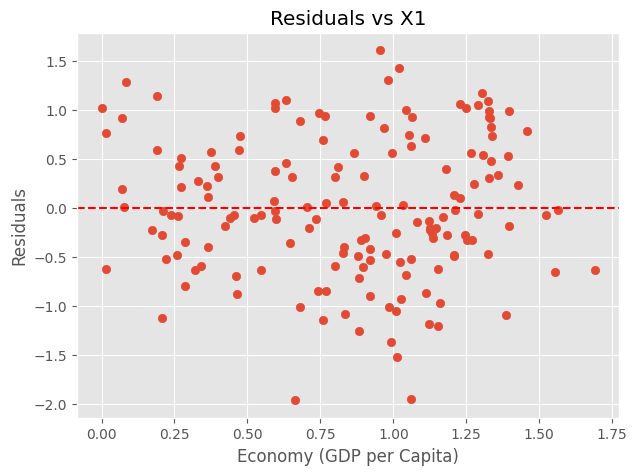

In [59]:
plt.figure(figsize=(7,5))

plt.scatter(df["X1"], residuals)

plt.axhline(0,color="red",linestyle="--")

plt.xlabel("Economy (GDP per Capita)")
plt.ylabel("Residuals")

plt.title("Residuals vs X1")

plt.show()

In [61]:
from statsmodels.stats.anova import anova_lm

def simple_linear_regression(data, predictor, prediction_value):

    print("="*90)
    print(f"Simple Linear Regression : Y vs {predictor}")
    print("="*90)

    formula = f"Y ~ {predictor}"

    model = smf.ols(formula=formula, data=data).fit()

    ############################################################
    # Fitted Model
    ############################################################

    intercept = model.params["Intercept"]
    slope = model.params[predictor]

    print("\nFITTED MODEL")
    print("-"*50)
    print(f"Y = {intercept:.6f} + ({slope:.6f}) × {predictor}")

    ############################################################
    # Regression Summary
    ############################################################

    print("\nREGRESSION SUMMARY")
    display(model.summary())

    ############################################################
    # ANOVA
    ############################################################

    print("\nANOVA TABLE")
    display(anova_lm(model))

    ############################################################
    # Coefficient Table
    ############################################################

    coef_table = pd.DataFrame({
        "Coefficient": model.params,
        "Std. Error": model.bse,
        "t Statistic": model.tvalues,
        "P-value": model.pvalues,
        "Lower 95% CI": model.conf_int()[0],
        "Upper 95% CI": model.conf_int()[1]
    })

    print("\nCOEFFICIENT TABLE")
    display(coef_table)

    ############################################################
    # Hypothesis Test
    ############################################################

    print("\nHYPOTHESIS TEST")

    pvalue = model.pvalues[predictor]

    print("P-value =", pvalue)

    if pvalue < 0.05:
        print("Decision : Reject H₀")
        print("Conclusion : Significant Linear Relationship")
    else:
        print("Decision : Fail to Reject H₀")
        print("Conclusion : No Significant Linear Relationship")

    ############################################################
    # Confidence Interval
    ############################################################

    print("\n95% CONFIDENCE INTERVAL")

    display(model.conf_int().rename(columns={
        0:"Lower Limit",
        1:"Upper Limit"
    }))

    ############################################################
    # R²
    ############################################################

    print("\nR²")

    print(f"R² = {model.rsquared:.4f}")

    print(f"Percentage Explained = {model.rsquared*100:.2f}%")

    ############################################################
    # Prediction
    ############################################################

    print("\nPREDICTION")

    new = pd.DataFrame({
        predictor:[prediction_value]
    })

    pred = model.get_prediction(new)

    display(pred.summary_frame(alpha=0.05))

    ############################################################
    # Residuals
    ############################################################

    residuals = model.resid
    fitted = model.fittedvalues

    ############################################################
    # QQ Plot
    ############################################################

    plt.figure(figsize=(6,5))
    sm.qqplot(residuals, line="45", fit=True)
    plt.title(f"Normal Q-Q Plot ({predictor})")
    plt.show()

    ############################################################
    # Residual vs Fitted
    ############################################################

    plt.figure(figsize=(6,5))

    plt.scatter(fitted, residuals)

    plt.axhline(0,color='red',linestyle='--')

    plt.xlabel("Fitted Values")
    plt.ylabel("Residuals")

    plt.title(f"Residuals vs Fitted ({predictor})")

    plt.show()

    ############################################################
    # Residual vs Predictor
    ############################################################

    plt.figure(figsize=(6,5))

    plt.scatter(data[predictor], residuals)

    plt.axhline(0,color='red',linestyle='--')

    plt.xlabel(predictor)

    plt.ylabel("Residuals")

    plt.title(f"Residuals vs {predictor}")

    plt.show()

    ############################################################
    # Standardized Residuals
    ############################################################

    influence = model.get_influence()

    std_resid = influence.resid_studentized_internal

    plt.figure(figsize=(6,5))

    plt.scatter(fitted,std_resid)

    plt.axhline(3,color='red',linestyle='--')
    plt.axhline(-3,color='red',linestyle='--')
    plt.axhline(0,color='black')

    plt.xlabel("Fitted Values")
    plt.ylabel("Standardized Residuals")

    plt.title(f"Standardized Residuals ({predictor})")

    plt.show()

    return model

Simple Linear Regression : Y vs X2

FITTED MODEL
--------------------------------------------------
Y = 2.290188 + (3.113424) × X2

REGRESSION SUMMARY


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.548
Model:                            OLS   Adj. R-squared:                  0.546
Method:                 Least Squares   F-statistic:                     189.5
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           9.92e-29
Time:                        22:15:53   Log-Likelihood:                -182.27
No. Observations:                 158   AIC:                             368.5
Df Residuals:                     156   BIC:                             374.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.2902      0.232      9.855      0.000       1.831       2.749
X2             3.1134      0.226     13.766      0.000       2.667       3.560
==============================================================================
Omnibus:                        2.999   Durbin-Watson:                   1.099
Prob(Omnibus):                  0.223   Jarque-Bera (JB):                2.110
Skew:                          -0.089   Prob(JB):                        0.348
Kurtosis:                       2.463   Cond. No.                         7.44
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


ANOVA TABLE


,df,sum_sq,mean_sq,F,PR(>F)
X2,1.0,112.899450,112.899450,189.511934,9.918850e-29
Residual,156.0,92.935119,0.595738,NaN,NaN



COEFFICIENT TABLE


...


HYPOTHESIS TEST
P-value = 9.918850000099894e-29
Decision : Reject H₀
Conclusion : Significant Linear Relationship

95% CONFIDENCE INTERVAL


,Lower Limit,Upper Limit
Intercept,1.831139,2.749237
X2,2.666689,3.560159



R²
R² = 0.5485
Percentage Explained = 54.85%

PREDICTION


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,6.412673,0.097181,6.220711,6.604634,4.876028,7.949317


<Figure size 600x500 with 0 Axes>

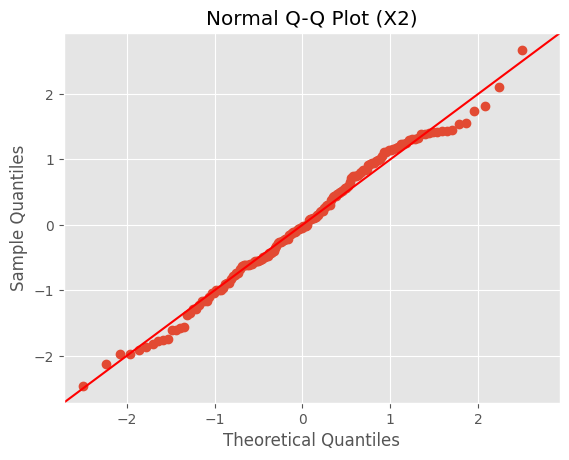

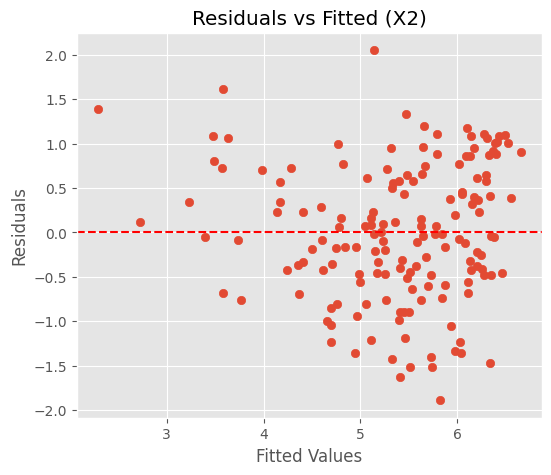

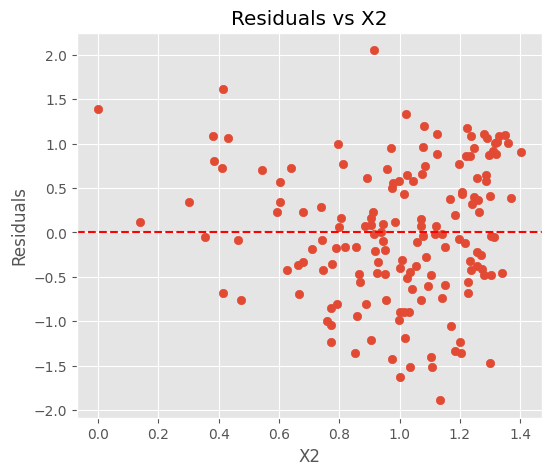

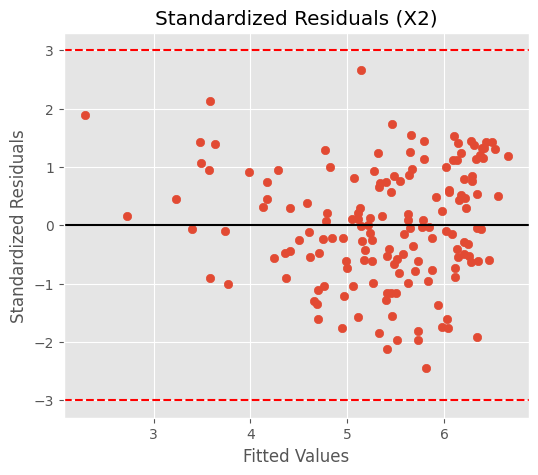

In [63]:
model_x2 = simple_linear_regression(
    df,
    predictor="X2",
    prediction_value=1.3241
)

Simple Linear Regression : Y vs X3

FITTED MODEL
--------------------------------------------------
Y = 3.260525 + (3.356093) × X3

REGRESSION SUMMARY


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.524
Model:                            OLS   Adj. R-squared:                  0.521
Method:                 Least Squares   F-statistic:                     172.1
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           5.79e-27
Time:                        22:16:05   Log-Likelihood:                -186.36
No. Observations:                 158   AIC:                             376.7
Df Residuals:                     156   BIC:                             382.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.2605      0.173     18.832      0.000       2.919       3.603
X3             3.3561      0.256     13.117      0.000       2.851       3.861
==============================================================================
Omnibus:                        1.834   Durbin-Watson:                   1.019
Prob(Omnibus):                  0.400   Jarque-Bera (JB):                1.862
Skew:                          -0.209   Prob(JB):                        0.394
Kurtosis:                       2.671   Cond. No.                         5.75
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


ANOVA TABLE


,df,sum_sq,mean_sq,F,PR(>F)
X3,1.0,107.953038,107.953038,172.0516,5.788896e-27
Residual,156.0,97.881531,0.627446,NaN,NaN



COEFFICIENT TABLE


...


HYPOTHESIS TEST
P-value = 5.788895505900734e-27
Decision : Reject H₀
Conclusion : Significant Linear Relationship

95% CONFIDENCE INTERVAL


,Lower Limit,Upper Limit
Intercept,2.918534,3.602516
X3,2.850693,3.861492



R²
R² = 0.5245
Percentage Explained = 52.45%

PREDICTION


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,6.657562,0.11628,6.427875,6.887249,5.076139,8.238985


<Figure size 600x500 with 0 Axes>

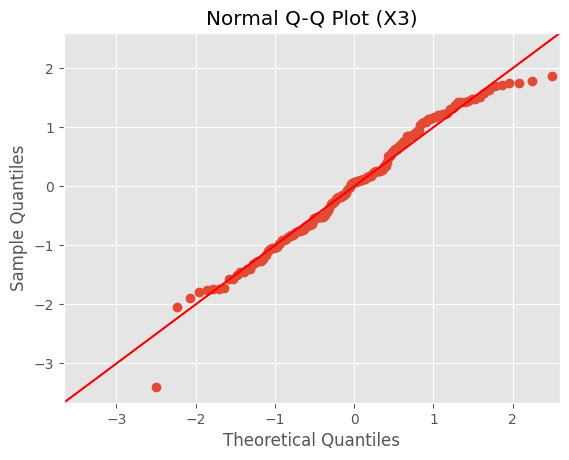

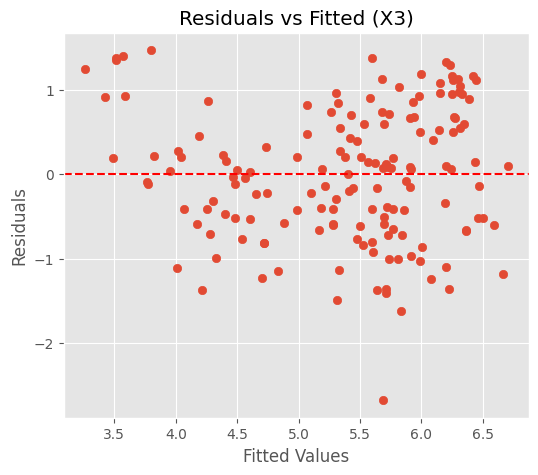

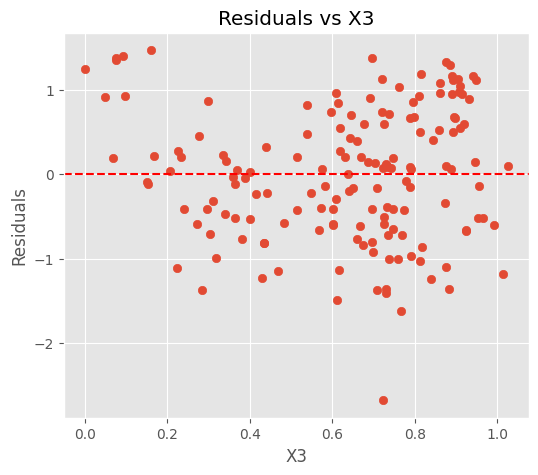

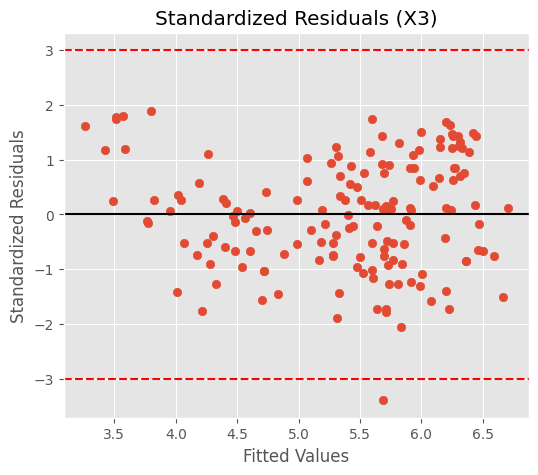

In [65]:
model_x3 = simple_linear_regression(
    df,
    predictor="X3",
    prediction_value=1.0122
)

Simple Linear Regression : Y vs X4

FITTED MODEL
--------------------------------------------------
Y = 3.525214 + (4.317441) × X4

REGRESSION SUMMARY


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     74.38
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           6.88e-15
Time:                        22:16:11   Log-Likelihood:                -214.29
No. Observations:                 158   AIC:                             432.6
Df Residuals:                     156   BIC:                             438.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.5252      0.227     15.505      0.000       3.076       3.974
X4             4.3174      0.501      8.624      0.000       3.329       5.306
==============================================================================
Omnibus:                        5.948   Durbin-Watson:                   0.608
Prob(Omnibus):                  0.051   Jarque-Bera (JB):                6.063
Skew:                          -0.453   Prob(JB):                       0.0482
Kurtosis:                       2.686   Cond. No.                         7.90
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


ANOVA TABLE


,df,sum_sq,mean_sq,F,PR(>F)
X4,1.0,66.456496,66.456496,74.381954,6.875808e-15
Residual,156.0,139.378072,0.893449,NaN,NaN



COEFFICIENT TABLE


...


HYPOTHESIS TEST
P-value = 6.875808160846938e-15
Decision : Reject H₀
Conclusion : Significant Linear Relationship

95% CONFIDENCE INTERVAL


,Lower Limit,Upper Limit
Intercept,3.076111,3.974318
X4,3.328608,5.306274



R²
R² = 0.3229
Percentage Explained = 32.29%

PREDICTION


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,5.792735,0.089401,5.616142,5.969327,3.917312,7.668157


<Figure size 600x500 with 0 Axes>

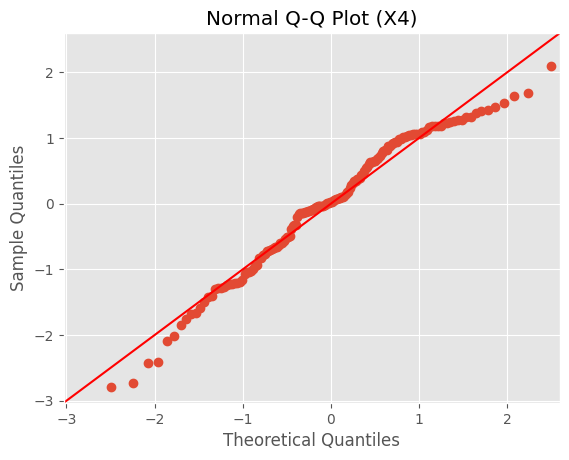

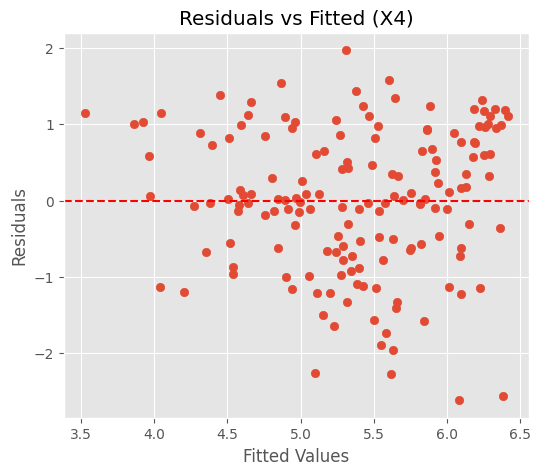

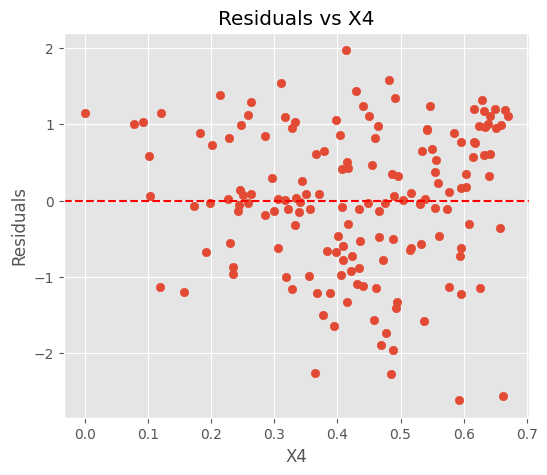

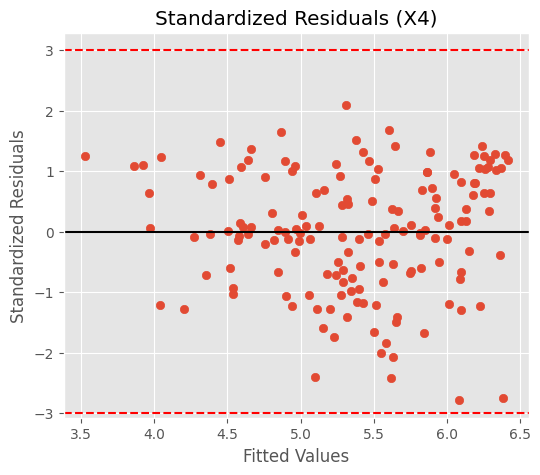

In [67]:
model_x4 = simple_linear_regression(
    df,
    predictor="X4",
    prediction_value=0.5252
)

Simple Linear Regression : Y vs X5

FITTED MODEL
--------------------------------------------------
Y = 4.835060 + (3.769816) × X5

REGRESSION SUMMARY


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.156
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     28.87
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           2.76e-07
Time:                        22:16:16   Log-Likelihood:                -231.67
No. Observations:                 158   AIC:                             467.3
Df Residuals:                     156   BIC:                             473.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.8351      0.131     36.898      0.000       4.576       5.094
X5             3.7698      0.702      5.373      0.000       2.384       5.156
==============================================================================
Omnibus:                        3.420   Durbin-Watson:                   0.275
Prob(Omnibus):                  0.181   Jarque-Bera (JB):                3.458
Skew:                          -0.350   Prob(JB):                        0.177
Kurtosis:                       2.813   Cond. No.                         8.53
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


ANOVA TABLE


,df,sum_sq,mean_sq,F,PR(>F)
X5,1.0,32.147638,32.147638,28.873972,2.763802e-07
Residual,156.0,173.686931,1.113378,NaN,NaN



COEFFICIENT TABLE


...


HYPOTHESIS TEST
P-value = 2.7638024252042326e-07
Decision : Reject H₀
Conclusion : Significant Linear Relationship

95% CONFIDENCE INTERVAL


,Lower Limit,Upper Limit
Intercept,4.576222,5.093898
X5,2.384027,5.155605



R²
R² = 0.1562
Percentage Explained = 15.62%

PREDICTION


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,6.137909,0.16482,5.812343,6.463475,4.028376,8.247441


<Figure size 600x500 with 0 Axes>

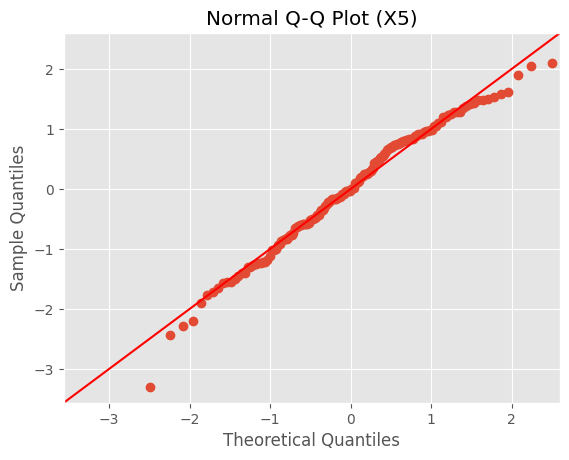

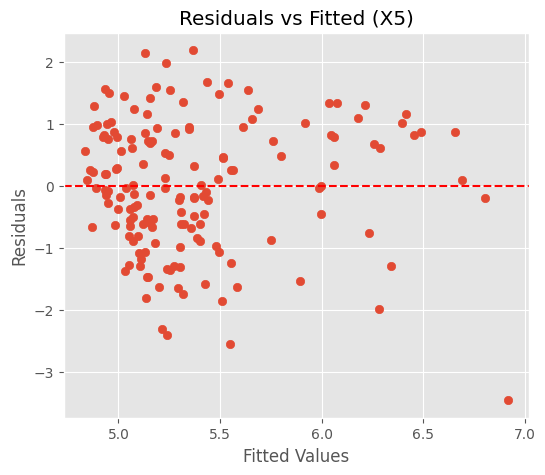

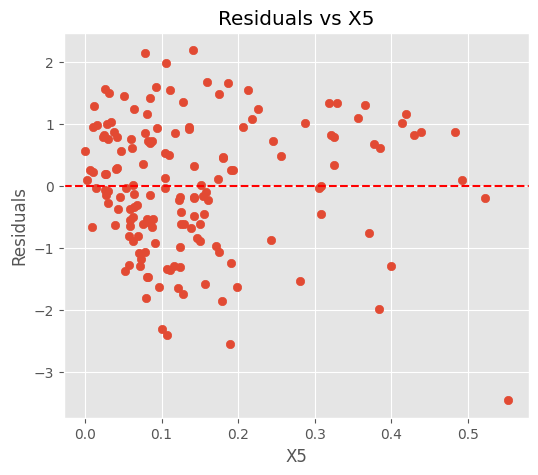

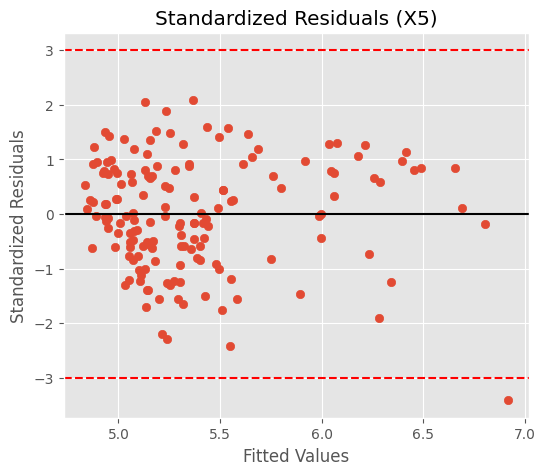

In [69]:
model_x5 = simple_linear_regression(
    df,
    predictor="X5",
    prediction_value=0.3456
)

Simple Linear Regression : Y vs X6

FITTED MODEL
--------------------------------------------------
Y = 4.988999 + (1.629764) × X6

REGRESSION SUMMARY


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     5.243
Date:                Fri, 14 Aug 2026   Prob (F-statistic):             0.0234
Time:                        22:16:25   Log-Likelihood:                -242.47
No. Observations:                 158   AIC:                             488.9
Df Residuals:                     156   BIC:                             495.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.9890      0.191     26.075      0.000       4.611       5.367
X6             1.6298      0.712      2.290      0.023       0.224       3.036
==============================================================================
Omnibus:                       10.635   Durbin-Watson:                   0.071
Prob(Omnibus):                  0.005   Jarque-Bera (JB):                4.346
Skew:                          -0.062   Prob(JB):                        0.114
Kurtosis:                       2.197   Cond. No.                         8.37
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


ANOVA TABLE


,df,sum_sq,mean_sq,F,PR(>F)
X6,1.0,6.692664,6.692664,5.242772,0.023379
Residual,156.0,199.141905,1.276551,NaN,NaN



COEFFICIENT TABLE


...


HYPOTHESIS TEST
P-value = 0.02337871591279692
Decision : Reject H₀
Conclusion : Significant Linear Relationship

95% CONFIDENCE INTERVAL


,Lower Limit,Upper Limit
Intercept,4.611067,5.366930
X6,0.223799,3.035729



R²
R² = 0.0325
Percentage Explained = 3.25%

PREDICTION


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,5.399047,0.09046,5.220362,5.577733,3.160136,7.637958


<Figure size 600x500 with 0 Axes>

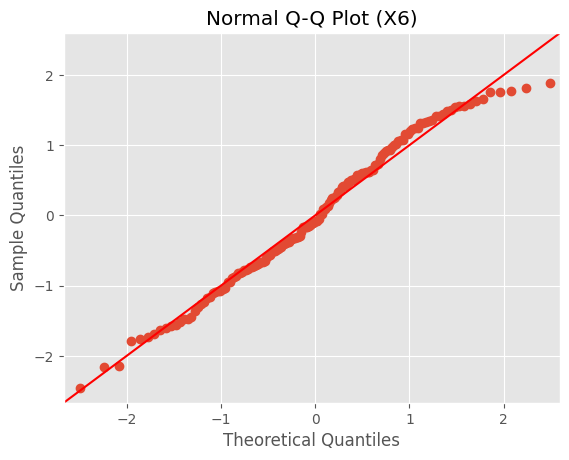

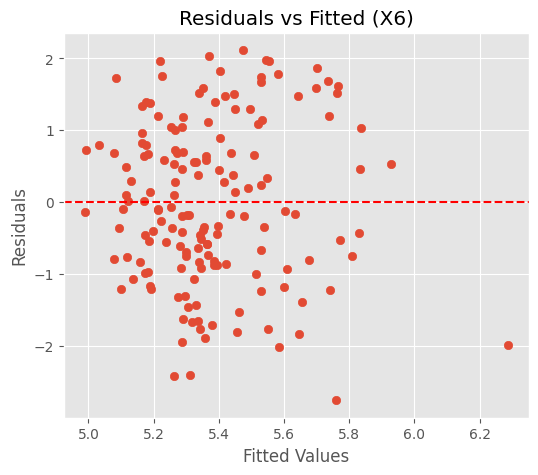

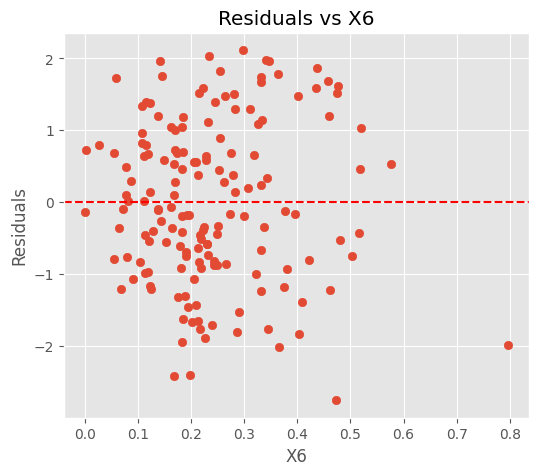

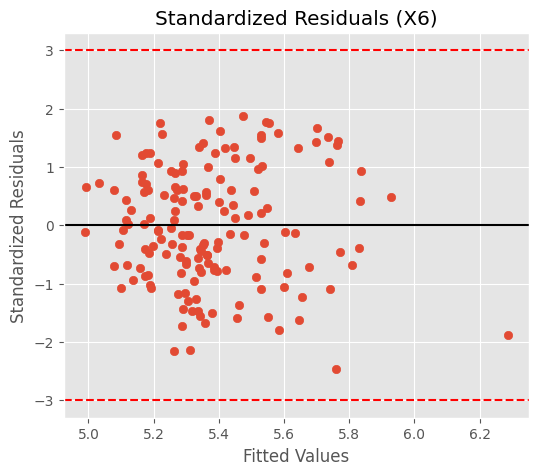

In [71]:
model_x6 = simple_linear_regression(
    df,
    predictor="X6",
    prediction_value=0.2516
)

# Multiple Linear Regression

## Model Fitting

A Multiple Linear Regression model is fitted to study the combined effect of all six explanatory variables on the Happiness Score.

The regression model is

\[
Y=\beta_0+\beta_1X_1+\beta_2X_2+\beta_3X_3+\beta_4X_4+\beta_5X_5+\beta_6X_6+\epsilon
\]

where

- **Y** : Happiness Score
- **X1** : Economy (GDP per Capita)
- **X2** : Family
- **X3** : Health (Life Expectancy)
- **X4** : Freedom
- **X5** : Trust (Government Corruption)
- **X6** : Generosity

In [74]:
mlr = smf.ols(
    "Y ~ X1 + X2 + X3 + X4 + X5 + X6",
    data=df
).fit()

In [76]:
coef = mlr.params

print("Fitted Regression Model\n")

print(
f"Y = {coef['Intercept']:.4f}"
f" + ({coef['X1']:.4f})X1"
f" + ({coef['X2']:.4f})X2"
f" + ({coef['X3']:.4f})X3"
f" + ({coef['X4']:.4f})X4"
f" + ({coef['X5']:.4f})X5"
f" + ({coef['X6']:.4f})X6"
)

Fitted Regression Model

Y = 1.8602 + (0.8607)X1 + (1.4089)X2 + (0.9753)X3 + (1.3334)X4 + (0.7845)X5 + (0.3889)X6


In [78]:
mlr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     87.81
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           1.04e-46
Time:                        22:19:06   Log-Likelihood:                -126.46
No. Observations:                 158   AIC:                             266.9
Df Residuals:                     151   BIC:                             288.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8602      0.190      9.766      0.000       1.484       2.237
X1             0.8607      0.220      3.907      0.000       0.425       1.296
X2             1.4089      0.223      6.327      0.000       0.969       1.849
X3             0.9753      0.316      3.084      0.002       0.350       1.600
X4             1.3334      0.385      3.463      0.001       0.573       2.094
X5             0.7845      0.437      1.797      0.074      -0.078       1.647
X6             0.3889      0.391      0.995      0.321      -0.384       1.161
==============================================================================
Omnibus:                        1.753   Durbin-Watson:                   1.506
Prob(Omnibus):                  0.416   Jarque-Bera (JB):                1.324
Skew:                          -0.180   Prob(JB):                        0.516
Kurtosis:                       3.268   Cond. No.                         21.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [80]:
from statsmodels.stats.anova import anova_lm

anova_table = anova_lm(mlr)

anova_table

,df,sum_sq,mean_sq,F,PR(>F)
X1,1.0,125.539976,125.539976,413.428604,4.411487e-45
X2,1.0,19.752378,19.752378,65.048588,2.090049e-13
X3,1.0,4.444964,4.444964,14.638169,1.901928e-04
X4,1.0,8.751990,8.751990,28.822077,2.935066e-07
X5,1.0,1.192792,1.192792,3.928106,4.930053e-02
X6,1.0,0.300449,0.300449,0.989440,3.214707e-01
Residual,151.0,45.852019,0.303656,NaN,NaN


## Global Test of Significance

The hypotheses are

\[
H_0:\beta_1=\beta_2=\cdots=\beta_6=0
\]

\[
H_1:\text{At least one regression coefficient is non-zero}
\]

The F-test is used to determine whether the model as a whole is statistically significant.

In [83]:
print("F Statistic :", mlr.fvalue)
print("P-value     :", mlr.f_pvalue)

if mlr.f_pvalue < 0.05:
    print("\nDecision : Reject H₀")
    print("Conclusion : The overall regression model is statistically significant.")
else:
    print("\nDecision : Fail to Reject H₀")
    print("Conclusion : The overall regression model is not statistically significant.")

F Statistic : 87.80916386355904
P-value     : 1.0428632327457699e-46

Decision : Reject H₀
Conclusion : The overall regression model is statistically significant.


In [85]:
coef_table = pd.DataFrame({
    "Coefficient": mlr.params,
    "Std Error": mlr.bse,
    "t Statistic": mlr.tvalues,
    "P-value": mlr.pvalues,
    "Lower 95% CI": mlr.conf_int()[0],
    "Upper 95% CI": mlr.conf_int()[1]
})

coef_table

,Coefficient,Std Error,t Statistic,P-value,Lower 95% CI,Upper 95% CI
Intercept,1.860185,0.190482,9.765654,9.153416e-18,1.483830,2.236540
X1,0.860657,0.220311,3.906550,1.408624e-04,0.425366,1.295948
X2,1.408892,0.222675,6.327119,2.692342e-09,0.968930,1.848853
X3,0.975309,0.316293,3.083562,2.432529e-03,0.350378,1.600240
X4,1.333433,0.385016,3.463321,6.944269e-04,0.572719,2.094147
X5,0.784538,0.436533,1.797203,7.430184e-02,-0.077963,1.647039
X6,0.388933,0.391003,0.994706,3.214707e-01,-0.383610,1.161476


## Test of Significance of Individual Regression Coefficients

Each regression coefficient is tested individually using a t-test.

The hypotheses are

\[
H_0:\beta_i=0
\]

\[
H_1:\beta_i\neq0
\]

for each predictor.

In [88]:
for variable in mlr.params.index[1:]:

    print("="*60)

    print(variable)

    p = mlr.pvalues[variable]

    print("P-value :", p)

    if p < 0.05:
        print("Decision : Reject H₀")
        print("Conclusion : Significant Predictor")
    else:
        print("Decision : Fail to Reject H₀")
        print("Conclusion : Not Significant")

X1
P-value : 0.0001408623547741841
Decision : Reject H₀
Conclusion : Significant Predictor
X2
P-value : 2.692342396256294e-09
Decision : Reject H₀
Conclusion : Significant Predictor
X3
P-value : 0.002432528870514448
Decision : Reject H₀
Conclusion : Significant Predictor
X4
P-value : 0.0006944268914325133
Decision : Reject H₀
Conclusion : Significant Predictor
X5
P-value : 0.07430183713884618
Decision : Fail to Reject H₀
Conclusion : Not Significant
X6
P-value : 0.3214707182098454
Decision : Fail to Reject H₀
Conclusion : Not Significant


In [90]:
print("R² :", round(mlr.rsquared,4))

print("Adjusted R² :", round(mlr.rsquared_adj,4))

R² : 0.7772
Adjusted R² : 0.7684


In [92]:
mlr.conf_int().rename(
    columns={
        0:"Lower Limit",
        1:"Upper Limit"
    }
)

,Lower Limit,Upper Limit
Intercept,1.483830,2.236540
X1,0.425366,1.295948
X2,0.968930,1.848853
X3,0.350378,1.600240
X4,0.572719,2.094147
X5,-0.077963,1.647039
X6,-0.383610,1.161476


In [94]:
new_observation = pd.DataFrame({
    "X1":[1.5478],
    "X2":[1.3241],
    "X3":[1.0122],
    "X4":[0.5252],
    "X5":[0.3456],
    "X6":[0.2516]
})

prediction = mlr.get_prediction(new_observation)

prediction.summary_frame(alpha=0.05)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,7.114342,0.107908,6.901137,7.327548,6.0049,8.223785


## Residual Analysis

Residual analysis is carried out to verify whether the assumptions of linear regression are satisfied.

The following diagnostic plots are examined:

- Residuals vs Fitted Values
- Normal Q-Q Plot
- Standardized Residuals
- Residuals vs Each Predictor

In [97]:
residuals = mlr.resid
fitted = mlr.fittedvalues

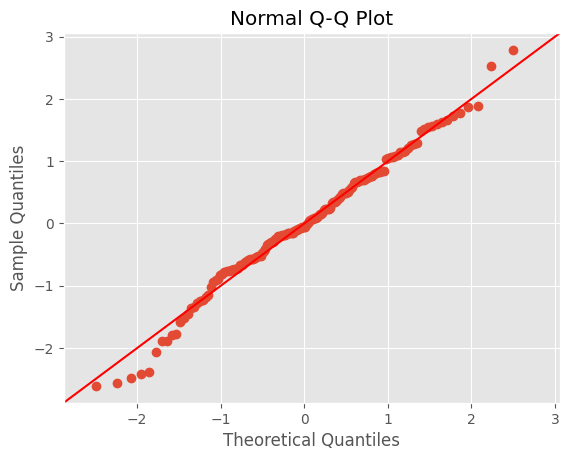

In [99]:
sm.qqplot(residuals, line='45', fit=True)

plt.title("Normal Q-Q Plot")

plt.show()

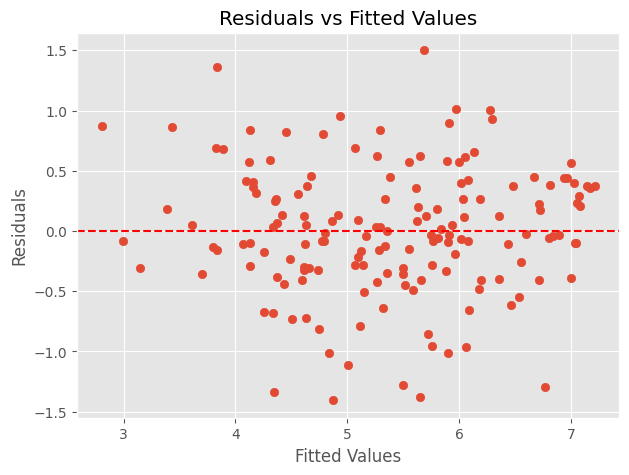

In [101]:
plt.figure(figsize=(7,5))

plt.scatter(fitted,residuals)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Fitted Values")

plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

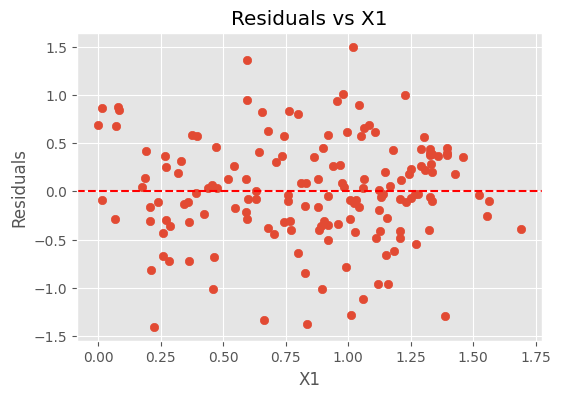

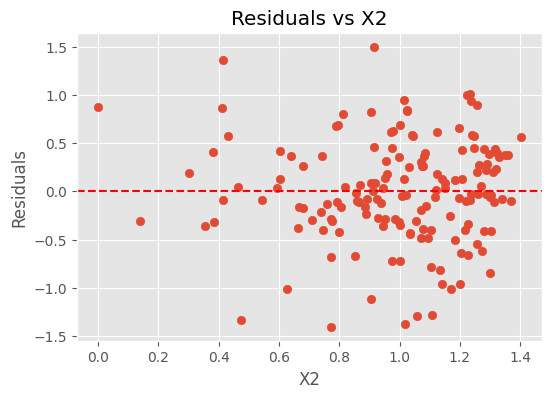

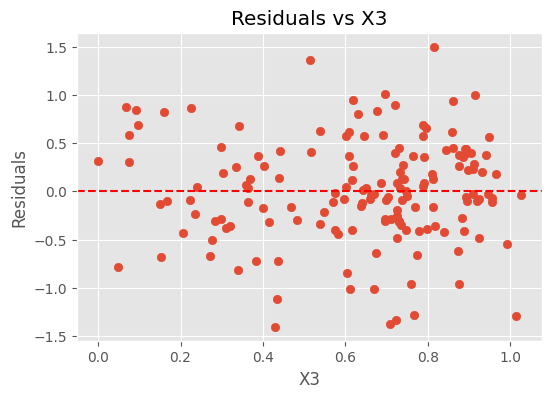

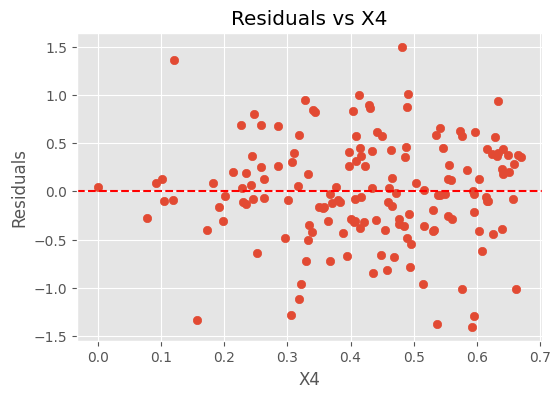

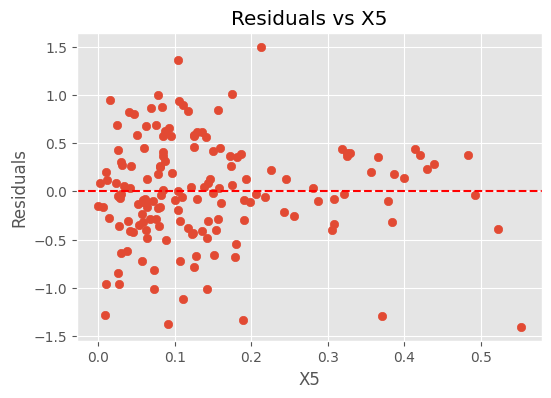

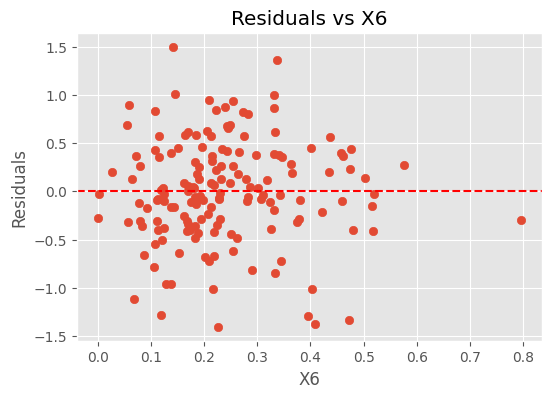

In [103]:
predictors = ["X1","X2","X3","X4","X5","X6"]

for predictor in predictors:

    plt.figure(figsize=(6,4))

    plt.scatter(df[predictor], residuals)

    plt.axhline(0,color='red',linestyle='--')

    plt.xlabel(predictor)

    plt.ylabel("Residuals")

    plt.title(f"Residuals vs {predictor}")

    plt.show()

### Standardized Residuals

Standardized residuals are used to detect potential outliers.

Observations with standardized residuals outside the interval (-3, 3) are generally considered unusual.

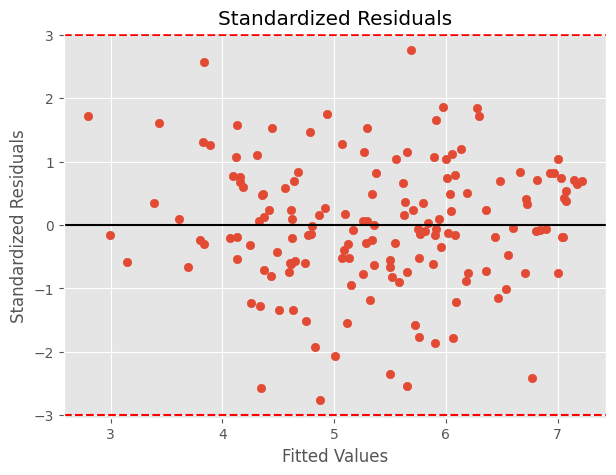

In [106]:
influence = mlr.get_influence()

standardized_residuals = influence.resid_studentized_internal

plt.figure(figsize=(7,5))

plt.scatter(fitted, standardized_residuals)

plt.axhline(3,color='red',linestyle='--')

plt.axhline(-3,color='red',linestyle='--')

plt.axhline(0,color='black')

plt.xlabel("Fitted Values")

plt.ylabel("Standardized Residuals")

plt.title("Standardized Residuals")

plt.show()

In [108]:
std_residual_df = pd.DataFrame({
    "Standardized Residual": standardized_residuals
})

std_residual_df.head()

,Standardized Residual
0,0.693327
1,1.039670
2,0.708378
3,0.653756
4,0.736863


## Variance Inflation Factor (VIF)

Variance Inflation Factor (VIF) is calculated to assess multicollinearity among the explanatory variables.

As a rule of thumb:

- VIF < 5 : Low multicollinearity
- 5 ≤ VIF < 10 : Moderate multicollinearity
- VIF ≥ 10 : High multicollinearity

In [111]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["X1","X2","X3","X4","X5","X6"]]

X = sm.add_constant(X)

vif = pd.DataFrame()

vif["Variable"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Variable,VIF
0,const,18.879268
1,X1,4.078140
2,X2,1.901853
3,X3,3.157655
4,X4,1.740443
5,X5,1.419584
6,X6,1.268610


## Overall Conclusion

The Multiple Linear Regression model was fitted to examine the combined effect of Economy, Family, Health, Freedom, Trust, and Generosity on the Happiness Score.

The overall F-test indicated that the regression model is statistically significant. Individual coefficient tests identified the predictors that significantly contribute to explaining the variation in Happiness Score.

Residual diagnostic plots did not reveal any major violations of the assumptions of linear regression. The standardized residuals also did not indicate the presence of influential outliers.

Overall, the fitted model provides an adequate representation of the relationship between the explanatory variables and the Happiness Score.

# Stepwise Regression

## Forward Selection using AIC

Stepwise Regression is a variable selection technique used to identify the most appropriate subset of predictors for the regression model.

In this analysis, **Forward Selection** is employed using the Akaike Information Criterion (AIC).

### Procedure

- Start with no predictor variables.
- Add one variable at a time.
- At each step, select the variable that results in the greatest improvement (lowest AIC).
- Continue until adding another variable does not reduce the AIC.

The final selected model is considered the optimal model according to the AIC criterion.

In [115]:
import statsmodels.formula.api as smf

def forward_selection(data, response, predictors):

    remaining = predictors.copy()
    selected = []

    current_aic = np.inf

    while remaining:

        scores = []

        for candidate in remaining:

            formula = response + " ~ " + " + ".join(selected + [candidate])

            model = smf.ols(formula=formula, data=data).fit()

            scores.append((model.aic, candidate))

        scores.sort()

        best_aic, best_candidate = scores[0]

        if best_aic < current_aic:

            current_aic = best_aic

            selected.append(best_candidate)

            remaining.remove(best_candidate)

        else:

            break

    formula = response + " ~ " + " + ".join(selected)

    final_model = smf.ols(formula=formula, data=data).fit()

    return final_model

In [117]:
predictors = ["X1","X2","X3","X4","X5","X6"]

step_model = forward_selection(
    df,
    response="Y",
    predictors=predictors
)

In [119]:
print(step_model.model.formula)

Y ~ X1 + X2 + X4 + X3 + X5


In [121]:
step_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.776
Model:                            OLS   Adj. R-squared:                  0.768
Method:                 Least Squares   F-statistic:                     105.2
Date:                Fri, 14 Aug 2026   Prob (F-statistic):           1.57e-47
Time:                        22:23:18   Log-Likelihood:                -126.97
No. Observations:                 158   AIC:                             265.9
Df Residuals:                     152   BIC:                             284.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.8982      0.187     10.173      0.000       1.530       2.267
X1             0.8053      0.213      3.778      0.000       0.384       1.227
X2             1.4164      0.223      6.365      0.000       0.977       1.856
X4             1.4426      0.369      3.909      0.000       0.713       2.172
X3             1.0338      0.311      3.327      0.001       0.420       1.648
X5             0.8540      0.431      1.982      0.049       0.003       1.705
==============================================================================
Omnibus:                        1.533   Durbin-Watson:                   1.509
Prob(Omnibus):                  0.465   Jarque-Bera (JB):                1.137
Skew:                          -0.177   Prob(JB):                        0.566
Kurtosis:                       3.217   Cond. No.                         21.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [123]:
from statsmodels.stats.anova import anova_lm

anova_lm(step_model)

,df,sum_sq,mean_sq,F,PR(>F)
X1,1.0,125.539976,125.539976,413.457329,3.273277e-45
X2,1.0,19.752378,19.752378,65.053108,2.026234e-13
X4,1.0,10.066517,10.066517,33.153386,4.564754e-08
X3,1.0,3.130437,3.130437,10.309879,1.614888e-03
X5,1.0,1.192792,1.192792,3.928379,4.928077e-02
Residual,152.0,46.152468,0.303635,NaN,NaN


In [125]:
coef_table = pd.DataFrame({
    "Coefficient": step_model.params,
    "Std Error": step_model.bse,
    "t Statistic": step_model.tvalues,
    "P-value": step_model.pvalues,
    "Lower 95% CI": step_model.conf_int()[0],
    "Upper 95% CI": step_model.conf_int()[1]
})

coef_table

,Coefficient,Std Error,t Statistic,P-value,Lower 95% CI,Upper 95% CI
Intercept,1.898207,0.186601,10.172540,7.301626e-19,1.529541,2.266874
X1,0.805342,0.213170,3.777931,2.264995e-04,0.384183,1.226501
X2,1.416401,0.222539,6.364723,2.190052e-09,0.976732,1.856071
X4,1.442593,0.369032,3.909127,1.391529e-04,0.713499,2.171687
X3,1.033820,0.310764,3.326701,1.102062e-03,0.419845,1.647795
X5,0.854032,0.430891,1.982014,4.928077e-02,0.002723,1.705341


In [127]:
comparison = pd.DataFrame({

    "Model":[
        "Multiple Linear Regression",
        "Stepwise Regression"
    ],

    "R²":[
        mlr.rsquared,
        step_model.rsquared
    ],

    "Adjusted R²":[
        mlr.rsquared_adj,
        step_model.rsquared_adj
    ],

    "AIC":[
        mlr.aic,
        step_model.aic
    ],

    "BIC":[
        mlr.bic,
        step_model.bic
    ]

})

comparison

,Model,R²,Adjusted R²,AIC,BIC
0,Multiple Linear Regression,0.777238,0.768387,266.910802,288.348967
1,Stepwise Regression,0.775779,0.768403,265.942732,284.318302


# Conclusion

This project analyzed the relationship between the Happiness Score and six socio-economic factors using both Simple and Multiple Linear Regression models.

### Summary

- Six Simple Linear Regression models were fitted to assess the individual effect of each predictor.
- A Multiple Linear Regression model was developed to evaluate the combined influence of all explanatory variables.
- The overall regression model was found to be statistically significant based on the F-test.
- Individual hypothesis tests identified the significant predictors of the Happiness Score.
- Confidence intervals and prediction intervals were computed for the regression coefficients and predicted values.
- Residual diagnostic plots indicated that the assumptions of linear regression were reasonably satisfied.
- Standardized residuals did not reveal any influential outliers.
- Forward Stepwise Regression was used to identify a parsimonious subset of predictors.

Overall, the analysis demonstrates that socio-economic factors such as Economy, Family, Health, Freedom, Trust, and Generosity play an important role in explaining variations in the Happiness Score across countries.